<a href="https://colab.research.google.com/github/zakku007/internship-toch-AI-ML/blob/main/Day6/Braintumer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os

In [ ]:
DATASET_DIR = '/content/Brain Tumor'

IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32

In [ ]:
train_ds = keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("\nClass names found:", class_names)

Found 253 files belonging to 2 classes.
Using 203 files for training.
Found 253 files belonging to 2 classes.
Using 50 files for validation.

Class names found: ['NO', 'YES']


In [ ]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y)).prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 578ms/step - accuracy: 0.6207 - loss: 0.6880 - val_accuracy: 0.8000 - val_loss: 0.5522
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 607ms/step - accuracy: 0.7340 - loss: 0.5245 - val_accuracy: 0.7800 - val_loss: 0.5616
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 658ms/step - accuracy: 0.7980 - loss: 0.4704 - val_accuracy: 0.8000 - val_loss: 0.5550
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 536ms/step - accuracy: 0.8030 - loss: 0.4300 - val_accuracy: 0.8200 - val_loss: 0.6367
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 660ms/step - accuracy: 0.8374 - loss: 0.4268 - val_accuracy: 0.8200 - val_loss: 0.5369
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 532ms/step - accuracy: 0.8473 - loss: 0.3569 - val_accuracy: 0.8000 - val_loss: 0.6130
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 528ms/step - accuracy: 0.8571 - loss: 0.3330 - val_accuracy: 0.8200 - val_loss: 0.5730
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 555ms/step - accuracy: 0.8719 - loss: 0.3032 - val_accuracy: 0.8000 - val_loss:

In [ ]:
val_loss, val_acc = model.evaluate(val_ds)
print(f'\nValidation Accuracy: {val_acc:.4f}')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.8600 - loss: 0.6754

Validation Accuracy: 0.8600


In [ ]:
predictions = model.predict(val_ds)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step


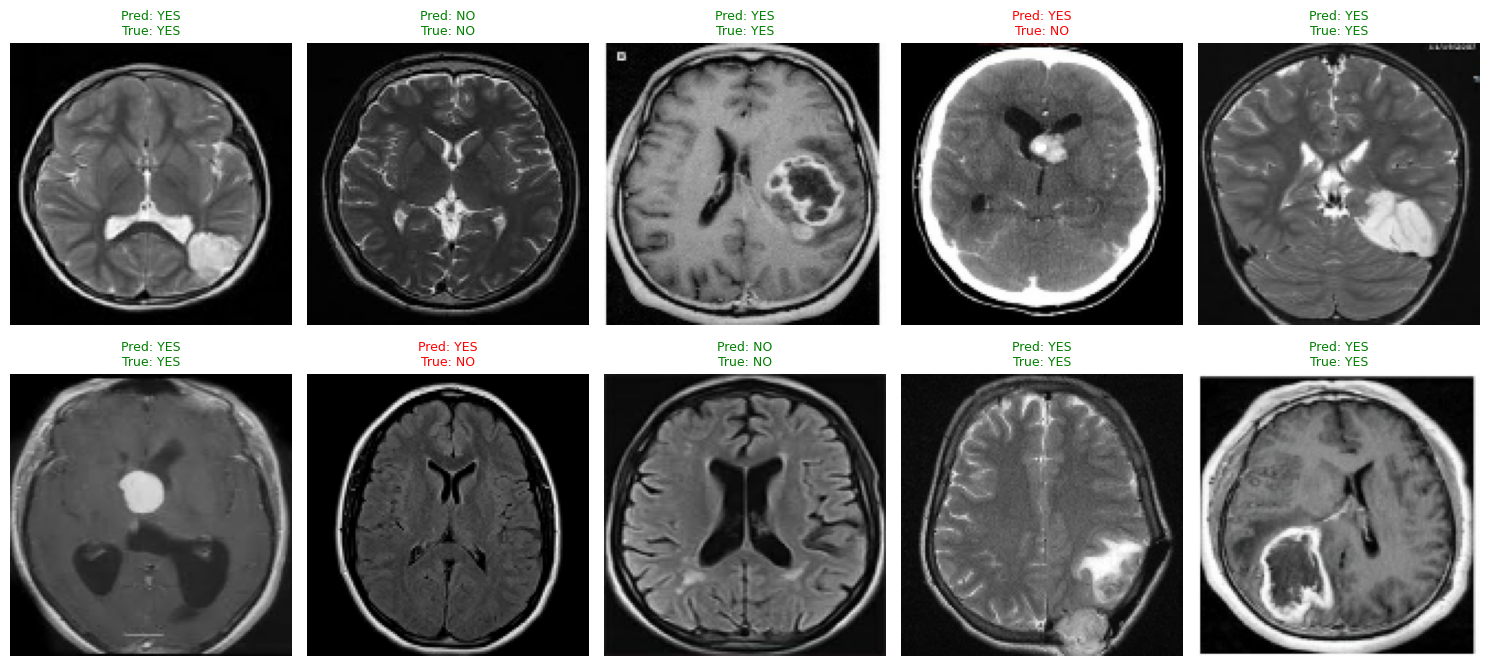

In [ ]:
# Grab a single batch and immediately run predictions on that exact same batch
x_val, y_val = next(iter(val_ds))
batch_predictions = model.predict(x_val)

plt.figure(figsize=(15, 7))
for i in range(10):
    if i >= len(x_val):
        break

    plt.subplot(2, 5, i+1)
    plt.imshow(x_val[i].numpy())

    # Use batch_predictions instead of global predictions array
    predicted_label = class_names[batch_predictions[i].argmax()]
    actual_label = class_names[y_val[i].numpy()]

    title_color = 'green' if predicted_label == actual_label else 'red'

    plt.title(f"Pred: {predicted_label}\nTrue: {actual_label}", color=title_color, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
import numpy as np

uploaded = files.upload()

for filename in uploaded.keys():
    img_path = filename

    img = keras.utils.load_img(img_path, target_size=IMAGE_SIZE)
    img_array = keras.utils.img_to_array(img)
    img_array_normalized = img_array / 255.0
    img_batch = np.expand_dims(img_array_normalized, axis=0)

    prediction = model.predict(img_batch)
    predicted_class_idx = np.argmax(prediction[0])
    predicted_label = class_names[predicted_class_idx]
    confidence = prediction[0][predicted_class_idx] * 100

    plt.figure(figsize=(4, 4))
    plt.imshow(img_array.astype("uint8"))
    plt.title(f"Prediction: {predicted_label}\nConfidence: {confidence:.2f}%")
    plt.axis('off')
    plt.show()